In [1]:
# Load libraries
import pandas as pd
from sklearn.ensemble import RandomForestClassifier # Import Random Forest Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for calculating the various required metrics calculation
import matplotlib.pyplot as plt
# from imblearn.over_sampling import SMOTE

In [2]:
# Read the dataset and look at the head to gauge the column names and whether column names actually exists
df_rf = pd.read_csv('./diabetes.csv')# YOUR CODE HERE
df_rf.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Perform the basic Null Check to decide whether imputation or drop is required
df_rf.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [4]:
# Split the data into features --> X and target values --> y
# Use Outcome as the target variable (i.e. y variable) and the rest as features (i.e. X variable)
cols = df_rf.columns

X = df_rf[cols[0:-1]]# YOUR CODE HERE
y = df_rf[cols[-1]]# YOUR CODE HERE

print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [5]:
# Perform a train test split with 70 - 30 train - test split
# Use random state as 0 but you are encouraged to play around with the values of random state as well
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, stratify=y)# YOUR CODE HERE

# smote = SMOTE(random_state=42)
# X_train, y_train = smote.fit_resample(X_train, y_train)

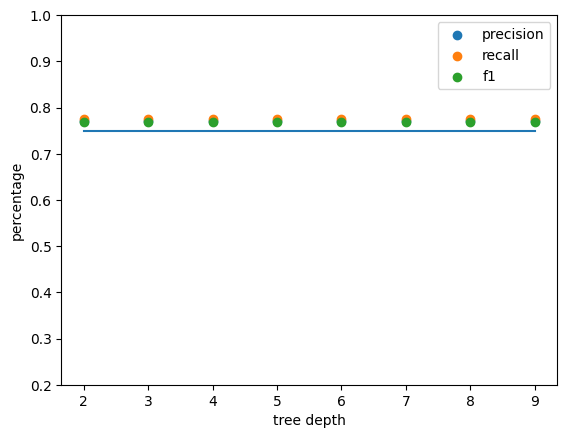

Most Optimal Metric:  2


In [6]:
from sklearn.metrics import f1_score, precision_score, accuracy_score, recall_score

def test():
  xAxis = []
  precisionVals = []
  recallVals = []
  f1Vals = []

  min = 2
  maxVal = 10
  best_f1_val = 0
  best_val = 0

  for val in range(min, maxVal):
    clf = RandomForestClassifier(criterion='entropy',
                                  min_samples_leaf=11,
                                  min_samples_split=2,
                                  max_features = 4,
                                  max_depth = 6,
                                  n_estimators = 36,
                                  random_state=4,
                                  )# YOUR CODE HERE

    # Train and Fit Decision Tree Classifer
    clf.fit(X_train, y_train)# YOUR CODE HERE

    dtree_y_pred = clf.predict(X_test)# YOUR CODE HERE

    precisionVals.append(precision_score(y_test, dtree_y_pred, average='weighted'))
    recallVals.append(recall_score(y_test, dtree_y_pred, average='weighted'))
    f1Vals.append(f1_score(y_test, dtree_y_pred, average='weighted'))

    xAxis.append(val)

  line = [.75 for i in range(min,maxVal)]

  plt.plot(xAxis, line)
  plt.scatter(xAxis, precisionVals, label=f'precision')
  plt.scatter(xAxis, recallVals, label=f'recall')
  plt.scatter(xAxis, f1Vals, label=f'f1')
  plt.xlabel('tree depth')
  plt.ylabel('percentage')
  plt.legend()
  plt.ylim(0.2, 1.0)
  plt.show()

  #max = __builtins__.max

  max_index = f1Vals.index(max(f1Vals))+min
  print("Most Optimal Metric: ", max_index)

'''
clf = RandomForestClassifier(criterion='gini',
                                min_samples_leaf=18,
                                min_samples_split=2,
                                max_features = 2,
                                class_weight='balanced',
                                random_state=10,
                                )
'''

test()

In [7]:
# Create Random Forest classifier object - change hyper params and get different results maybe answer with best values
# Play around with the values of the RandomForestClassifier - change criterion and max_depth to find the best f1 score
# Prescribed values - criterion = "gini", min_samples_leaf = 1, min_samples_split = 10, max_features='auto', random_state=1

from sklearn.metrics import f1_score, precision_score, accuracy_score, recall_score

rf_clf = RandomForestClassifier(criterion='entropy',
                                  min_samples_leaf=11,
                                  min_samples_split=2,
                                  max_features = 4,
                                  max_depth = 6,
                                  n_estimators = 36,
                                  random_state=4,
                                  )# YOUR CODE HERE

                                # Train and fit Random Forest Classifer
# YOUR CODE HERE
# Predict the response for test dataset
# YOUR CODE HERE

rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

'''
rf_clf = RandomForestClassifier(criterion='entropy',
                                min_samples_leaf=15,
                                min_samples_split=15,
                                max_features = 4,
                                max_depth=6,
                                bootstrap=True,
                                n_estimators=40,
                                random_state=10
                                )# YOUR CODE HERE
'''

# Report the accuracy, precision, recall and f1_score into the variables labelled thus - you may try out various combinations referring here: https://scikit-
# learn.org/stable/modules/classes.html#classification-metrics
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_y_true = y_test
accuracy = accuracy_score(rf_y_true, y_pred)# Put the value of accuracy here -- 1.1 of Gradescope tests
precision = precision_score(rf_y_true, y_pred, average='weighted')# Put the value of precision here -- 1.2 of Gradescope tests
recall = recall_score(rf_y_true, y_pred, average='weighted')# Put the value of recall here -- 1.3 of Gradescope tests
f1_score = f1_score(rf_y_true, y_pred, average='weighted')# Put the value of F1 score here -- 1.4 of Gradescope tests

print("Accuracy:", accuracy) # -- 1.1
print("Precision Score:", precision) # -- 1.2
print("Recall Score: ", recall) # -- 1.3
print("F1 Score: ", f1_score) # -- 1.4

Accuracy: 0.7748917748917749
Precision Score: 0.7699001035367982
Recall Score:  0.7748917748917749
F1 Score:  0.7692631004732916


In [8]:
# Here a template for writing the function for getting the tpr, fpr and threshold
# as well as AUC values is given as well as a simple way to plot the ROC curve
# you need to find out the predicted probabilities for the classifier you have
# written - using: redict_proba() function
# Pass these probabilities along with the y_true values into this function as
# specified and find the values mentioned above

# and report the AUC value and plot the ROC curve
from sklearn.metrics import roc_curve, auc

rf_auc = 0

def plot_roc(rf_y_true, rf_probs):
  # Use sklearn.metrics.roc_curve() to get the values based on what the funciton
  # returns - Read documentation here:
  # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html
  rf_fpr, rf_tpr, rf_threshold = roc_curve(rf_y_true, rf_probs)# YOUR CODE HERE

  # Use sklearn.metrics.auc() to get the AUC score of your model - Read documentation here:
  #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html
  rf_auc_val = auc(rf_fpr, rf_tpr) # Find out and put the AUC score here -- 1.5 of Gradescope tests

  # Report the AUC score for the model you have created
  print('AUC=%0.2f'%rf_auc_val) # -- 1.5

  # Plot the ROC curve using the probabilities and the true y values as passed into the fuction we have defined here
  plt.plot(rf_fpr, rf_tpr, label = 'AUC=%0.2f'%rf_auc_val, color = 'darkorange')
  plt.legend(loc = 'lower right')
  plt.plot([0,1], [0,1], 'b--')
  plt.xlim([0,1])
  plt.ylim([0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.show()
  return rf_auc_val

AUC=0.82


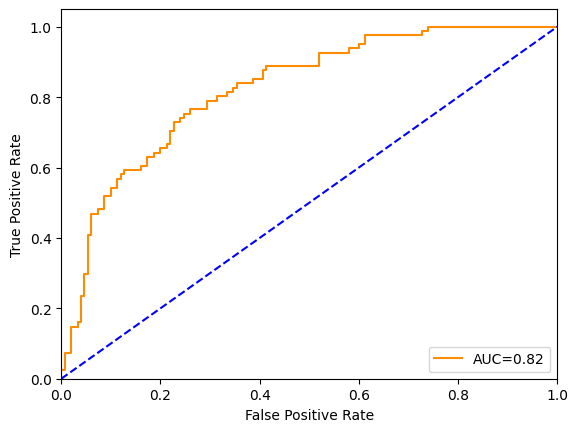

In [9]:
# We pass in the following parameters to the custom function we have written. For
# details as to why we do this - Read here:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
#sklearn.metrics.roc_auc_score
rf_probs = rf_clf.predict_proba(X_test) [:,1] # This gives the classifiers'

# prediction probabilities for each class for the predicted samples
rf_auc = plot_roc(rf_y_true, rf_probs) # This is where 1.5 is graded in Gradescope

In [10]:
# Report which cross validation value of k gave the best result as well as the
# accuracy score - use StrafiedKFold Cross Validation method - Read about it here:
#https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedS
# tratifiedKFold.html
#sklearn.model_selection.RepeatedStratifiedKFold

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

max_acc, max_k = 0, 0
for k in range(2, 11):
  skfold = StratifiedKFold(random_state=100, shuffle=True, n_splits=k) # YOUR CODE HERE FOR: StratifiedKFold() - use random_state = 100,
  shuffle = True
  results_skfold_acc = (cross_val_score(rf_clf, X, y, cv = skfold)).mean() * 100.0

  if results_skfold_acc > max_acc:# conditional check for getting max value and corresponding k value
    max_acc = results_skfold_acc
    max_k = k

  # YOUR CODE HERE
  print("Accuracy: %.2f%%" % (results_skfold_acc))

Accuracy: 76.30%
Accuracy: 76.43%
Accuracy: 76.17%
Accuracy: 76.83%
Accuracy: 76.56%
Accuracy: 76.96%
Accuracy: 75.65%
Accuracy: 76.32%
Accuracy: 75.65%


In [11]:
best_accuracy = max_acc # Put the accuracy score here from the values that you got -- 1.6 of Gradescope tests
best_k_fold = max_k # Put the value of k that gives the best accuracy here # -- 1.7 of Gradescope tests
print(best_accuracy, best_k_fold)


76.95817943524365 7
